## Importing Necessary Libraries

In [127]:
import pandas as pd 
import numpy as np  
import matplotlib.pyplot as plt
import seaborn as sns


In [128]:
# Load the dataset
df = pd.read_csv('../data/raw_telecom.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [129]:
# Check for data summary and statistics
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [130]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [131]:

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

C:\Users\G POORNIMADEVI\AppData\Local\Temp\ipykernel_2472\4237058013.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [132]:
# check for missing values
for feature in df.columns:
    if df[feature].isnull().sum() > 0:
        print(f"{feature}: {df[feature].isnull().sum()}")

In [133]:
#Check for duplicates
df.duplicated().sum()

np.int64(0)

## Exploratory Data Analysis

1.Univariate Analysis


In [134]:
#Univariate analysis of the target variable

df['Churn'].value_counts(normalize=True)



Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

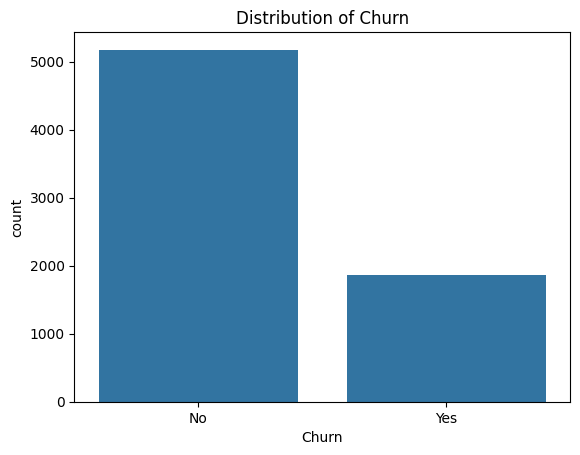

In [135]:
ax = sns.countplot(x='Churn', data=df)
plt.title('Distribution of Churn')
plt.show()

In [136]:
# Most customers did not churn, indicating a class imbalance in the dataset. This is important to consider when building predictive models, as it may affect the performance of the model and require techniques to address the imbalance.

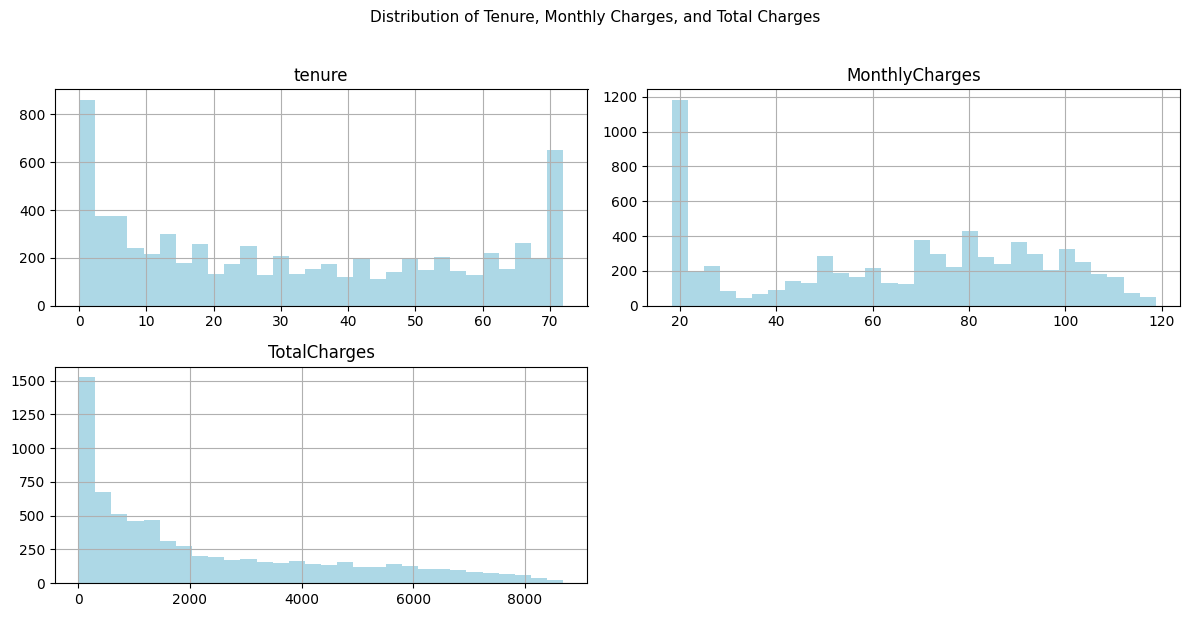

In [137]:
# Distribution of Tenure, Monthly Charges, and Total Charges
num_cols = ['tenure','MonthlyCharges','TotalCharges']

axes = df[num_cols].hist(figsize=(12,6), bins=30, color='lightblue')
plt.suptitle('Distribution of Tenure, Monthly Charges, and Total Charges', y=1.02, fontsize=11)
plt.tight_layout()
plt.show()

In [138]:
# TotalCustomers with lower tenure appear more frequently in the dataset, suggesting that newer customers form a significant portion of the customer base and may be more vulnerable to churn compared to long-term customers.


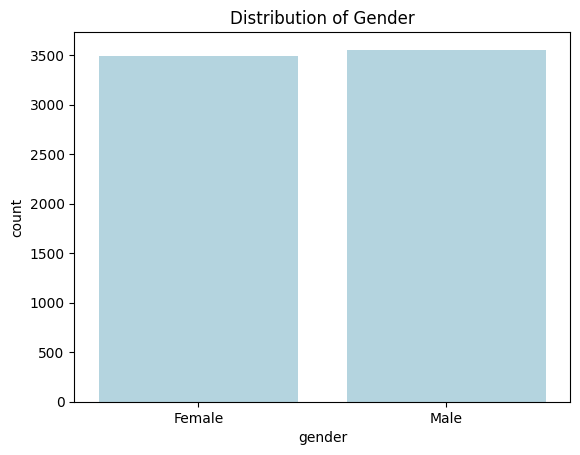

In [139]:
# Distribution of gender
ax = sns.countplot(x='gender', data=df,color='lightblue')
plt.title('Distribution of Gender')
plt.show()

In [140]:
# Both male and female customers are almost equally represented in the dataset, indicating that gender may not be a significant factor in customer churn for this telecom company.

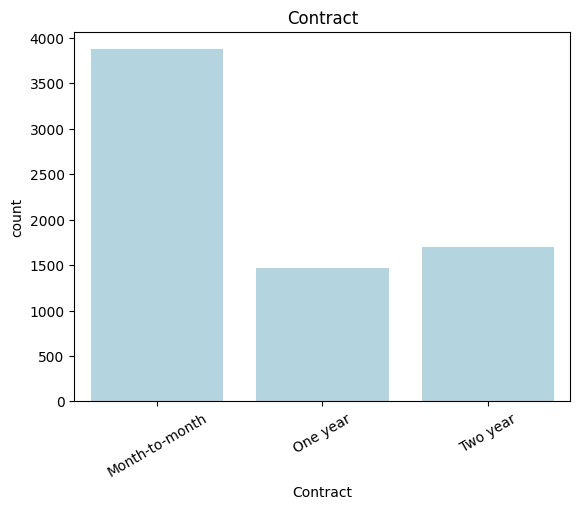

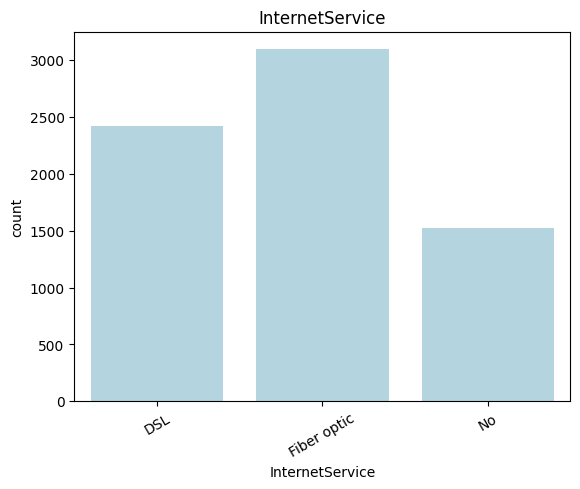

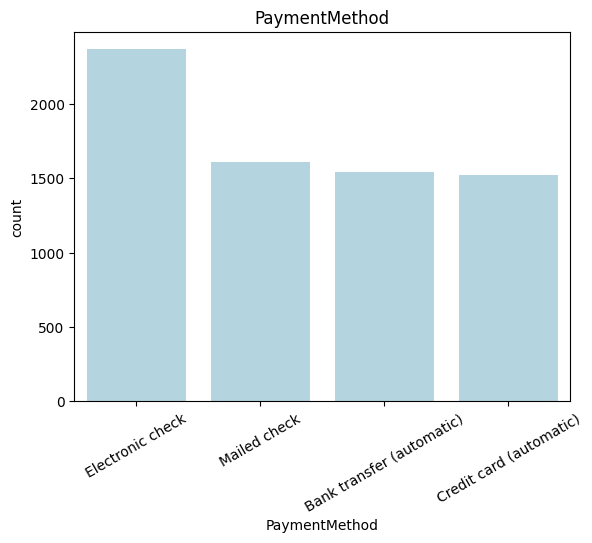

In [141]:
# Distribution of Contract, Internet Service, and Payment Method
cat_cols = ['Contract','InternetService','PaymentMethod']

for col in cat_cols:
    ax = sns.countplot(x=col, data=df,color='lightblue')
    plt.title(col)
    plt.xticks(rotation=30)
    plt.show()

In [142]:
# Month-to-month contracts are the most common, followed by two-year and one-year contracts. Fiber optic is the most common internet service, followed by DSL and no internet service. Electronic check is the most common payment method, followed by mailed check, bank transfer, and credit card.

2. Bivariate Analysis

In [143]:
def plot_categorical_distribution(feature):
    ax = sns.countplot(x=feature, hue='Churn', data=df,color='lightblue')
    plt.title(f'Distribution of {feature} by Churn')
    plt.xticks(rotation=30)
    plt.show()

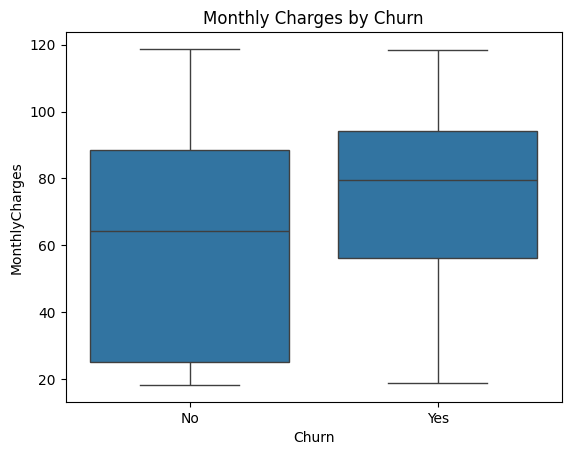

In [144]:
# Boxplot of Monthly Charges by Churn
ax = sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('Monthly Charges by Churn')
plt.show()

In [145]:
# Average monthly charges are higher for customers who churned compared to those who did not, suggesting that higher monthly charges may be associated with an increased likelihood of churn.

In [146]:
df['MonthlyCharges'].groupby(df['Churn']).mean()

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

C:\Users\G POORNIMADEVI\AppData\Local\Temp\ipykernel_2472\482354242.py:2: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:lightblue'` for the same effect.

  ax = sns.countplot(x=feature, hue='Churn', data=df,color='lightblue')


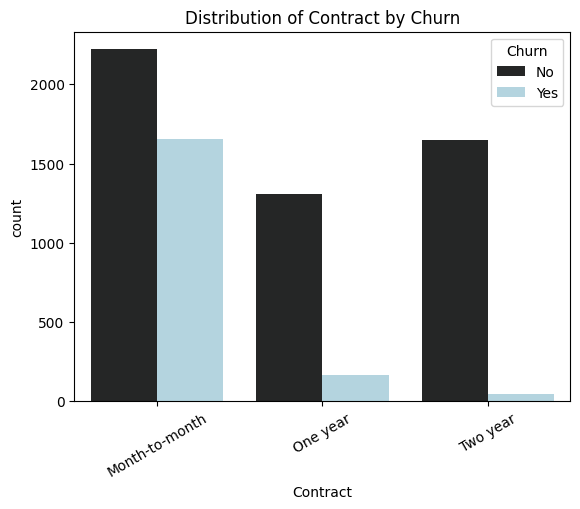

In [147]:
# Distribution of Contract by Churn
plot_categorical_distribution('Contract')

In [148]:
# month-to-month contracts have a higher proportion of customers who churned compared to one-year and two-year contracts, indicating that customers with month-to-month contracts may be more likely to churn.

In [149]:
df["Contract"].groupby(df["Churn"]).value_counts(normalize=True)*100

Churn  Contract      
No     Month-to-month    42.906842
       Two year          31.832238
       One year          25.260920
Yes    Month-to-month    88.550027
       One year           8.881755
       Two year           2.568218
Name: proportion, dtype: float64

C:\Users\G POORNIMADEVI\AppData\Local\Temp\ipykernel_2472\482354242.py:2: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:lightblue'` for the same effect.

  ax = sns.countplot(x=feature, hue='Churn', data=df,color='lightblue')


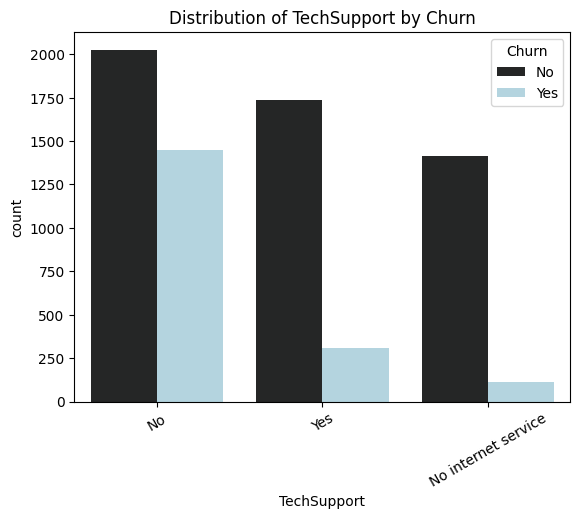

In [150]:
# Distribution of TechSupport by Churn
plot_categorical_distribution('TechSupport')

In [151]:
# most customers who churned did not have tech support, suggesting that lack of tech support may be associated with an increased likelihood of churn.

In [152]:
df["TechSupport"].groupby(df["Churn"]).value_counts(normalize=True)*100

Churn  TechSupport        
No     No                     39.176652
       Yes                    33.513722
       No internet service    27.309625
Yes    No                     77.367576
       Yes                    16.586410
       No internet service     6.046014
Name: proportion, dtype: float64

C:\Users\G POORNIMADEVI\AppData\Local\Temp\ipykernel_2472\482354242.py:2: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:lightblue'` for the same effect.

  ax = sns.countplot(x=feature, hue='Churn', data=df,color='lightblue')


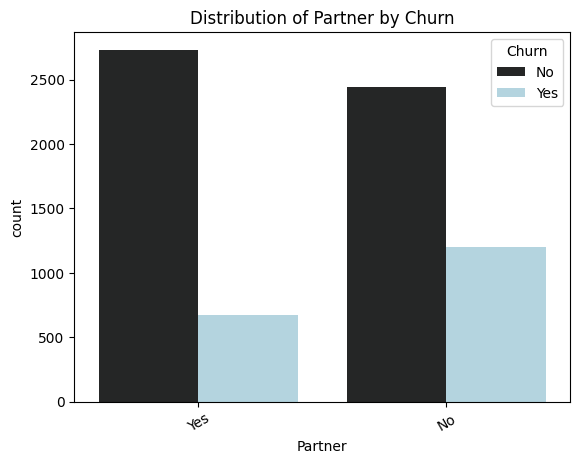

In [153]:
# Distribution of partner by Churn
plot_categorical_distribution('Partner')

In [154]:
# Most of the customers who churned did not have a partner, suggesting that customers without a partner may be more likely to churn compared to those with a partner.

In [155]:
df["Partner"].groupby(df["Churn"]).value_counts(normalize=True)*100

Churn  Partner
No     Yes        52.821801
       No         47.178199
Yes    No         64.205457
       Yes        35.794543
Name: proportion, dtype: float64

C:\Users\G POORNIMADEVI\AppData\Local\Temp\ipykernel_2472\482354242.py:2: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:lightblue'` for the same effect.

  ax = sns.countplot(x=feature, hue='Churn', data=df,color='lightblue')


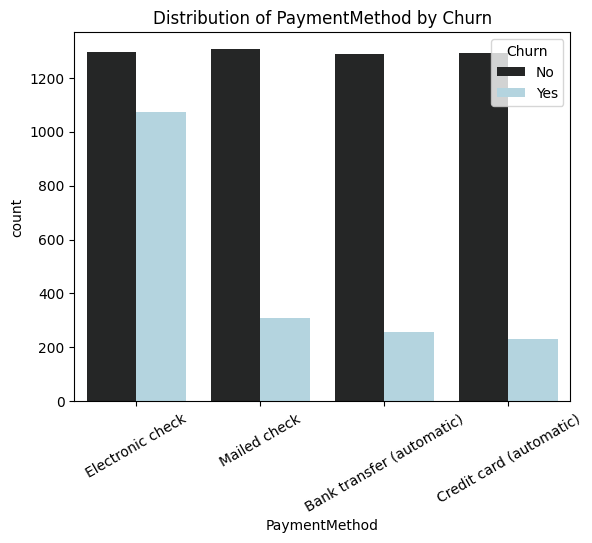

In [156]:
# Distribution of PaymentMethod by Churn
plot_categorical_distribution('PaymentMethod')

In [157]:
# Electronic check is the most common payment method among customers who churned, suggesting that customers using electronic checks may be more likely to churn compared to those using other payment methods.

In [158]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [159]:
df['PaymentMethod'].groupby(df['Churn']).value_counts(normalize=True)*100

Churn  PaymentMethod            
No     Mailed check                 25.202938
       Electronic check             25.009664
       Credit card (automatic)      24.932354
       Bank transfer (automatic)    24.855044
Yes    Electronic check             57.303371
       Mailed check                 16.479401
       Bank transfer (automatic)    13.804173
       Credit card (automatic)      12.413055
Name: proportion, dtype: float64

C:\Users\G POORNIMADEVI\AppData\Local\Temp\ipykernel_2472\482354242.py:2: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:lightblue'` for the same effect.

  ax = sns.countplot(x=feature, hue='Churn', data=df,color='lightblue')


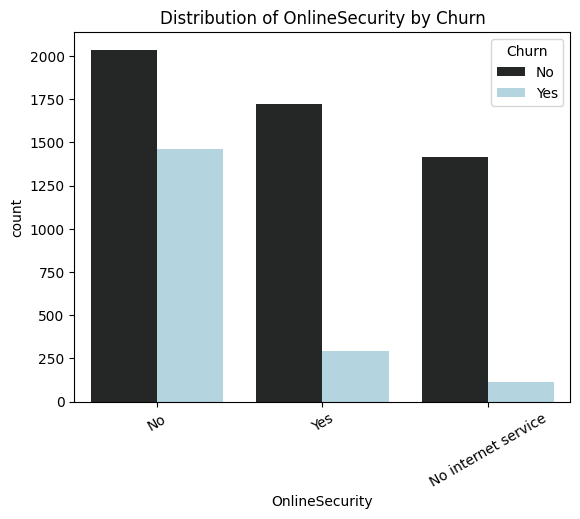

C:\Users\G POORNIMADEVI\AppData\Local\Temp\ipykernel_2472\482354242.py:2: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:lightblue'` for the same effect.

  ax = sns.countplot(x=feature, hue='Churn', data=df,color='lightblue')


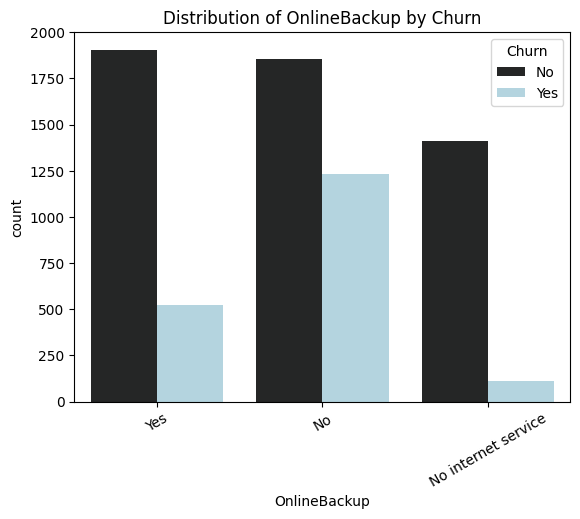

C:\Users\G POORNIMADEVI\AppData\Local\Temp\ipykernel_2472\482354242.py:2: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:lightblue'` for the same effect.

  ax = sns.countplot(x=feature, hue='Churn', data=df,color='lightblue')


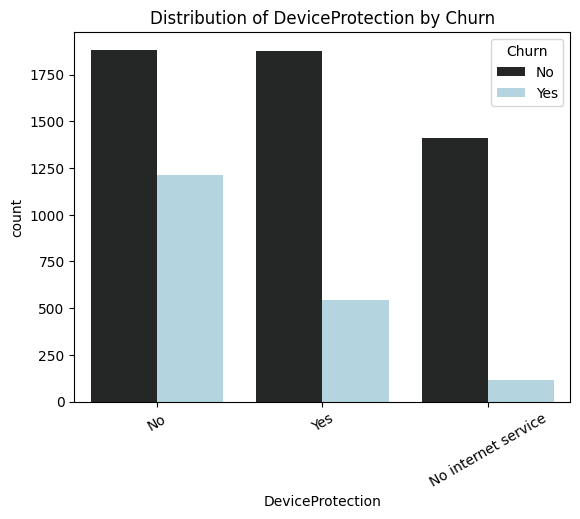

C:\Users\G POORNIMADEVI\AppData\Local\Temp\ipykernel_2472\482354242.py:2: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:lightblue'` for the same effect.

  ax = sns.countplot(x=feature, hue='Churn', data=df,color='lightblue')


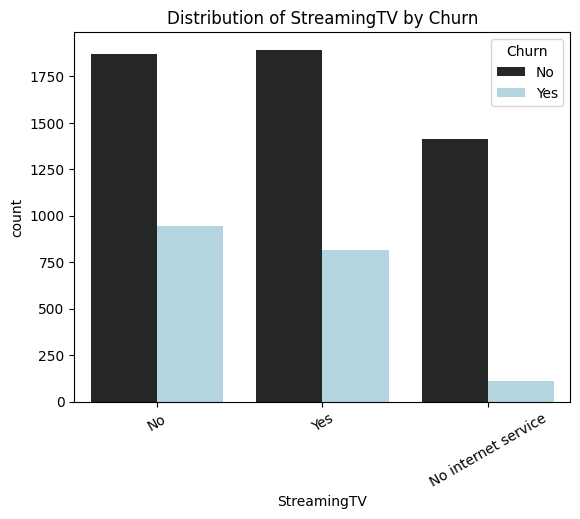

C:\Users\G POORNIMADEVI\AppData\Local\Temp\ipykernel_2472\482354242.py:2: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:lightblue'` for the same effect.

  ax = sns.countplot(x=feature, hue='Churn', data=df,color='lightblue')


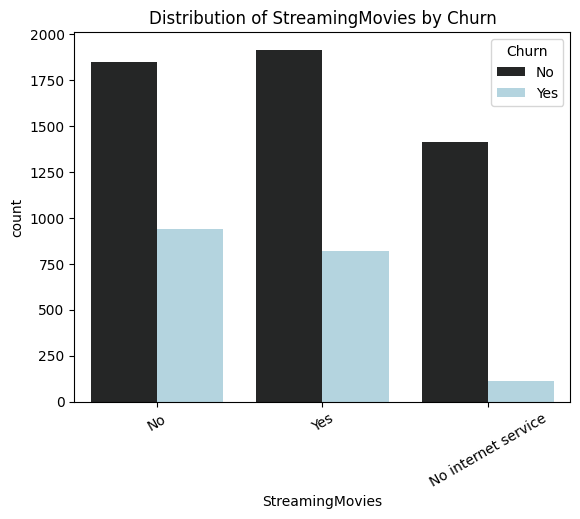

In [160]:
cols=['OnlineSecurity','OnlineBackup','DeviceProtection','StreamingTV','StreamingMovies']
for col in cols:
    plot_categorical_distribution(col)

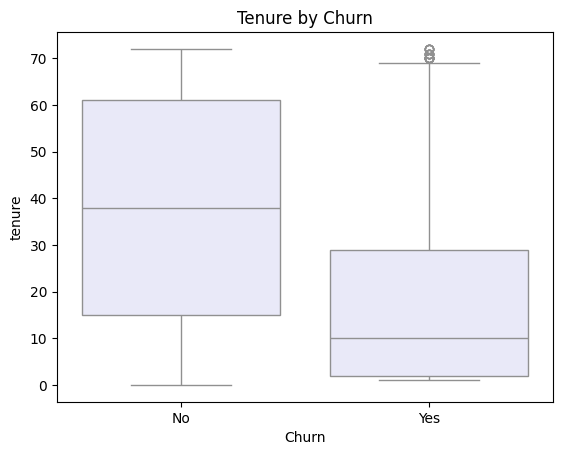

In [161]:
# Boxplot of Tenure by Churn
ax = sns.boxplot(x='Churn', y='tenure', data=df,color='lavender')
plt.title('Tenure by Churn')
plt.show()

In [162]:
# Average tenure is lower for customers who churned compared to those who did not, suggesting that customers with shorter tenure may be more likely to churn.

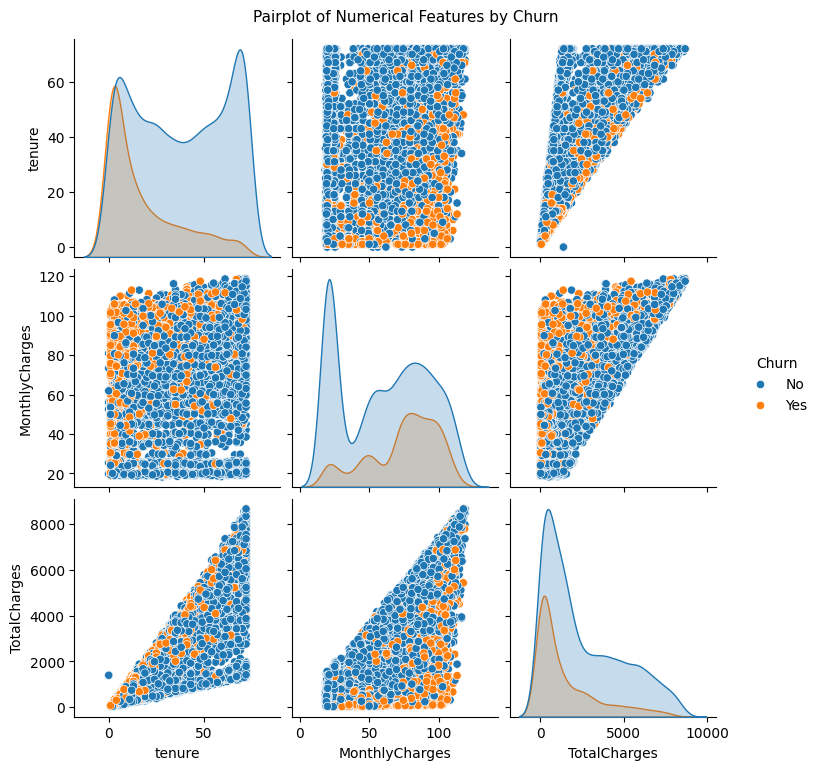

In [163]:
# Multivariate analysis of numerical features
g = sns.pairplot(df, hue='Churn', vars=num_cols)
g.fig.suptitle('Pairplot of Numerical Features by Churn', y=1.02, fontsize=11)
plt.show()

In [164]:
# The pairplot indicates that customers with lower tenure and higher monthly charges are more likely to churn, while long-term customers with higher total charges tend to remain with the company, suggesting customer loyalty increases over time.

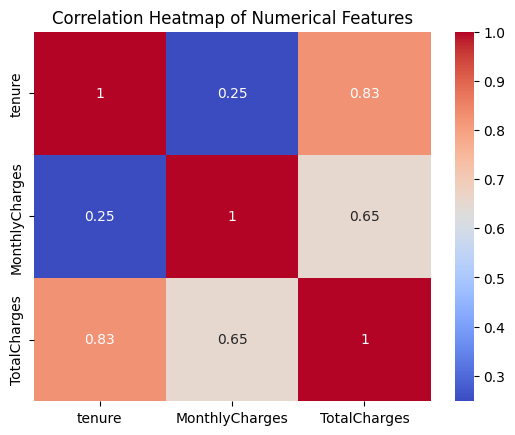

In [165]:
corr=df[num_cols].corr()
ax = sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

In [166]:
# Tenure is highly correlated with Total Charges, which is expected as customers with longer tenure are likely to have higher total charges. Monthly Charges has a moderate correlation with Total Charges, indicating that higher monthly charges may contribute to higher total charges over time. However, Monthly Charges has a low correlation with Tenure, suggesting that monthly charges do not significantly vary based on how long a customer has been with the company.

Overall, churn is highest among customers with month-to-month contracts, low tenure, higher monthly charges, no tech support, and payment by electronic check.

In [167]:
# Export the cleaned dataset for modeling
df.to_csv('../data/cleaned_telecom.csv', index=False)